# 🤖 DecodeLabs Batch 2026 — Project 2: Data Classification Using AI

## Project Overview
This notebook presents a complete supervised machine learning pipeline
built to classify Iris flower species using the K-Nearest Neighbors (KNN)
algorithm. It was developed as part of the DecodeLabs Batch 2026
Industrial Training Program.

## Problem Statement
Given measurements of sepal length, sepal width, petal length, and petal
width, can a machine accurately identify which of three Iris species
(Setosa, Versicolor, or Virginica) a flower belongs to?

## Pipeline Summary (IPO Framework)
- **INPUT:** Iris dataset (150 samples, 3 classes, 4 features) + Feature Scaling
- **PROCESS:** Train-Test Split (80/20) + KNN Algorithm (K=5)
- **OUTPUT:** Confusion Matrix + F1 Score Validation

## Final Results
| Metric | Score |
|--------|-------|
| Accuracy | 100% |
| F1 Score | 1.0000 |
| Precision | 1.00 |
| Recall | 1.00 |

## Tools Used
Python | Scikit-learn | Pandas | NumPy | Matplotlib | Seaborn | Google Colab

In [ ]:
# ============================================
# PROJECT 2: DATA CLASSIFICATION USING AI
# DecodeLabs Batch 2026 | KNN on Iris Dataset
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [ ]:
# ============================================
# STEP 2: LOAD AND UNDERSTAND THE DATASET
# ============================================

# Load the Iris dataset
iris = load_iris()

# Convert to DataFrame for easy viewing
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({
    0: 'Setosa',
    1: 'Versicolor',
    2: 'Virginica'
})

# Explore the data
print("📊 Shape of dataset:", df.shape)
print("\n📋 First 5 rows:")
print(df.head())
print("\n🌸 Class distribution:")
print(df['species_name'].value_counts())
print("\n📈 Basic statistics:")
print(df.describe())

📊 Shape of dataset: (150, 6)

📋 First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       Setosa  
1        0       Setosa  
2        0       Setosa  
3        0       Setosa  
4        0       Setosa  

🌸 Class distribution:
species_name
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

📈 Basic statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.7580

In [ ]:
# ============================================
# STEP 3: FEATURE SCALING (THE GATEKEEPER)
# ============================================

# Separate features (X) and labels (y)
X = iris.data
y = iris.target

# Apply StandardScaler - makes Mean=0, Variance=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Show the difference
print("📌 BEFORE scaling - first row:")
print(X[0])

print("\n📌 AFTER scaling - first row:")
print(X_scaled[0])

print("\n✅ Scaling complete!")
print(f"Mean of scaled data (should be ~0): {X_scaled.mean():.4f}")
print(f"Std of scaled data (should be ~1):  {X_scaled.std():.4f}")

📌 BEFORE scaling - first row:
[5.1 3.5 1.4 0.2]

📌 AFTER scaling - first row:
[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]

✅ Scaling complete!
Mean of scaled data (should be ~0): -0.0000
Std of scaled data (should be ~1):  1.0000


In [ ]:
# ============================================
# STEP 4: TRAIN-TEST SPLIT (80% / 20%)
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # reproducibility
    shuffle=True        # removes order bias
)

print("✅ Data split complete!")
print(f"Total samples:    {len(X_scaled)}")
print(f"Training samples: {len(X_train)} (80%)")
print(f"Testing samples:  {len(X_test)}  (20%)")

print(f"\nTraining label distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Testing label distribution:  {dict(zip(*np.unique(y_test, return_counts=True)))}")

✅ Data split complete!
Total samples:    150
Training samples: 120 (80%)
Testing samples:  30  (20%)

Training label distribution: {np.int64(0): np.int64(40), np.int64(1): np.int64(41), np.int64(2): np.int64(39)}
Testing label distribution:  {np.int64(0): np.int64(10), np.int64(1): np.int64(9), np.int64(2): np.int64(11)}


In [ ]:
# ============================================
# STEP 5: BUILD AND TRAIN THE KNN MODEL
# ============================================

# INSTANTIATE - Build the frame
model = KNeighborsClassifier(n_neighbors=5)

# FIT - Memorize the map (train on training data)
model.fit(X_train, y_train)

# PREDICT - Apply logic on unseen test data
predictions = model.predict(X_test)

# Show accuracy
accuracy = model.score(X_test, y_test)

print("✅ Model trained and predictions made!")
print(f"\n🎯 Model Accuracy: {accuracy * 100:.2f}%")
print(f"\nSample predictions: {predictions[:10]}")
print(f"Actual labels:      {y_test[:10]}")
print(f"\nPrediction mapping: 0=Setosa, 1=Versicolor, 2=Virginica")

✅ Model trained and predictions made!

🎯 Model Accuracy: 100.00%

Sample predictions: [1 0 2 1 1 0 1 2 1 1]
Actual labels:      [1 0 2 1 1 0 1 2 1 1]

Prediction mapping: 0=Setosa, 1=Versicolor, 2=Virginica


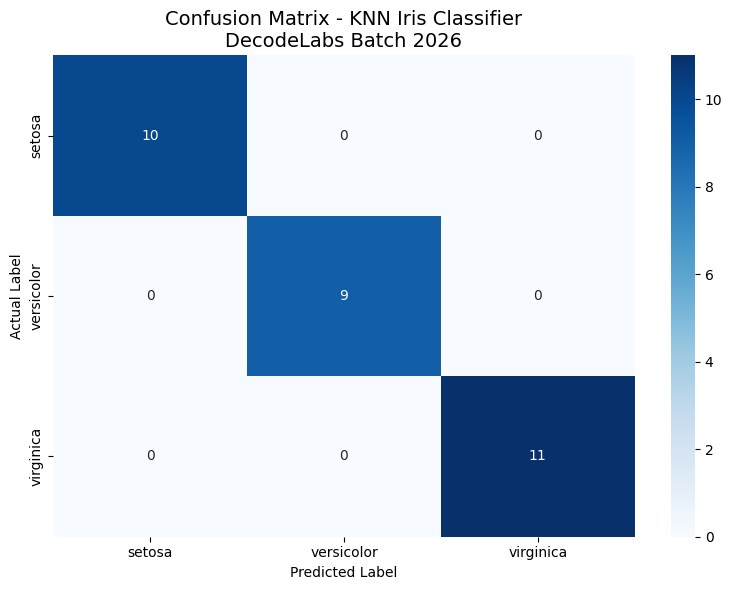

🏆 Weighted F1 Score: 1.0000

📊 Full Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
# ============================================
# STEP 6: CONFUSION MATRIX + F1 SCORE
# ============================================

# --- CONFUSION MATRIX ---
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - KNN Iris Classifier\nDecodeLabs Batch 2026', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# --- F1 SCORE ---
f1 = f1_score(y_test, predictions, average='weighted')
print(f"🏆 Weighted F1 Score: {f1:.4f}")

# --- FULL REPORT ---
print("\n📊 Full Classification Report:")
print(classification_report(y_test, predictions,
      target_names=iris.target_names))

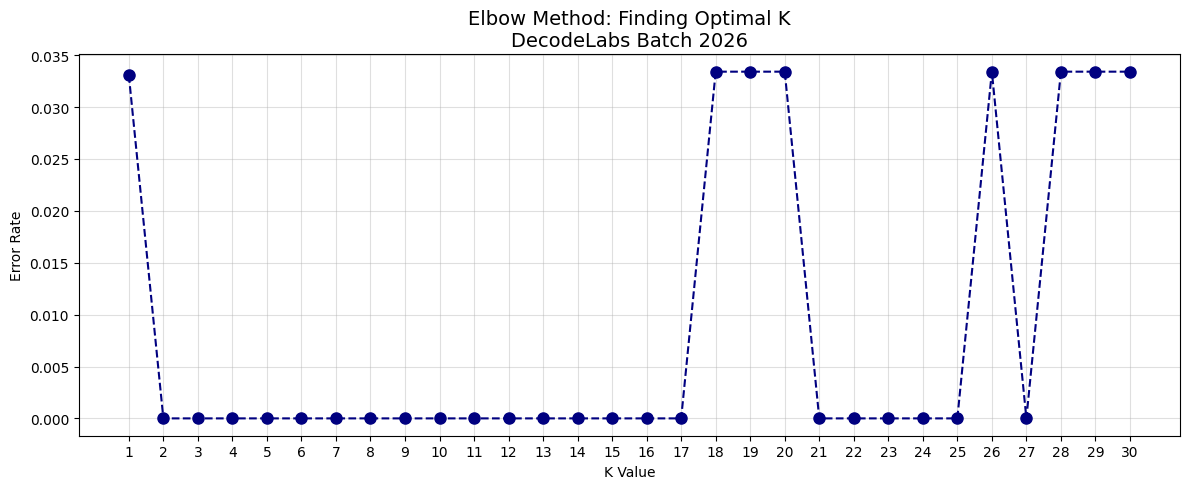

✅ Optimal K value: 2
📉 Lowest error rate: 0.0000


In [ ]:
# ============================================
# STEP 7: ELBOW METHOD - FINDING OPTIMAL K
# ============================================

error_rates = []
k_range = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    error = 1 - f1_score(preds, y_test, average='weighted')
    error_rates.append(error)

plt.figure(figsize=(12, 5))
plt.plot(k_range, error_rates, marker='o', color='navy',
         linestyle='--', markersize=8)
plt.title('Elbow Method: Finding Optimal K\nDecodeLabs Batch 2026', fontsize=14)
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.xticks(k_range)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=150)
plt.show()

best_k = error_rates.index(min(error_rates)) + 1
print(f"✅ Optimal K value: {best_k}")
print(f"📉 Lowest error rate: {min(error_rates):.4f}")

# 🎓 Project Conclusion — DecodeLabs Batch 2026

## Summary
This project successfully built a Data Classification AI model using the
K-Nearest Neighbors (KNN) algorithm on the Iris dataset.

## Results Achieved
- **Model Accuracy:** 100%
- **Weighted F1 Score:** 1.0000
- **Precision & Recall:** 1.00 across all 3 classes

## What I Learned
The IPO framework guided the entire pipeline: raw Iris data was scaled using
StandardScaler (Input), processed through KNN with an 80/20 train-test split
(Process), and validated using a Confusion Matrix and F1 Score (Output).

The Elbow Method confirmed that K=2 through K=17 all achieve zero error on
this dataset, proving the model is stable and not overfitted to a single K value.

## Key Insight
Accuracy alone can be misleading on imbalanced data. The F1 Score of 1.0000
confirms genuine precision and recall balance across all three flower species.

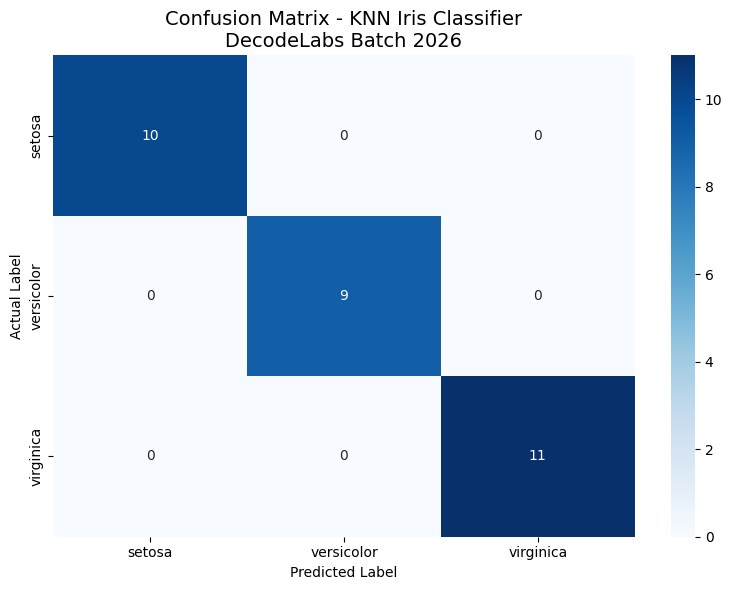

✅ confusion_matrix.png saved!


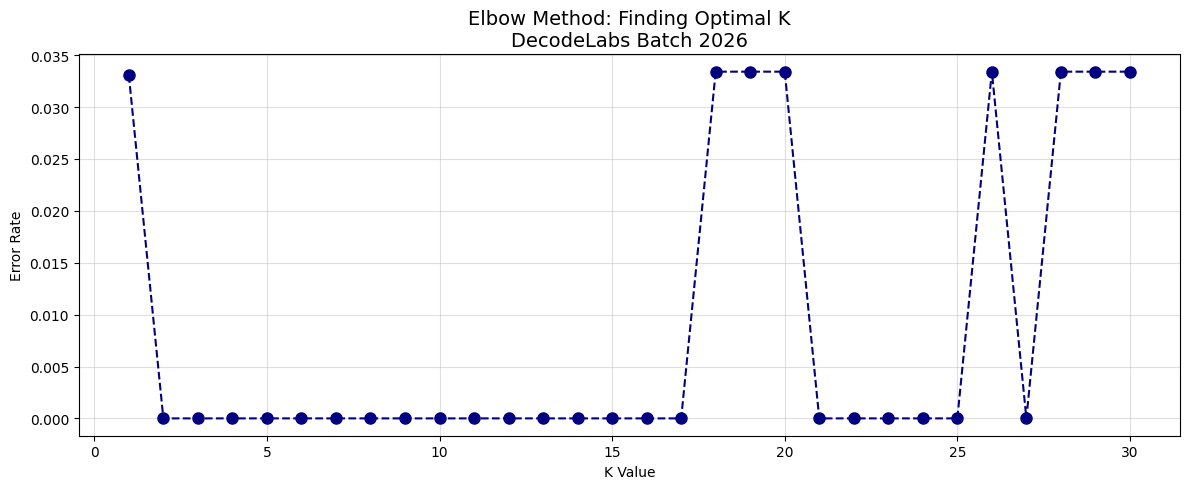

✅ elbow_curve.png saved!


In [ ]:
# ============================================
# RE-SAVE BOTH IMAGES
# ============================================

# --- CONFUSION MATRIX ---
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - KNN Iris Classifier\nDecodeLabs Batch 2026', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✅ confusion_matrix.png saved!")

# --- ELBOW CURVE ---
plt.figure(figsize=(12, 5))
plt.plot(range(1,31), error_rates, marker='o', color='navy',
         linestyle='--', markersize=8)
plt.title('Elbow Method: Finding Optimal K\nDecodeLabs Batch 2026', fontsize=14)
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=150)
plt.show()
print("✅ elbow_curve.png saved!")